Matplotlib is building the font cache; this may take a moment.


Loading final dataset...
Cleaned dataset shape: (104, 6)

Baseline Mean Absolute Error (MAE): $45.89


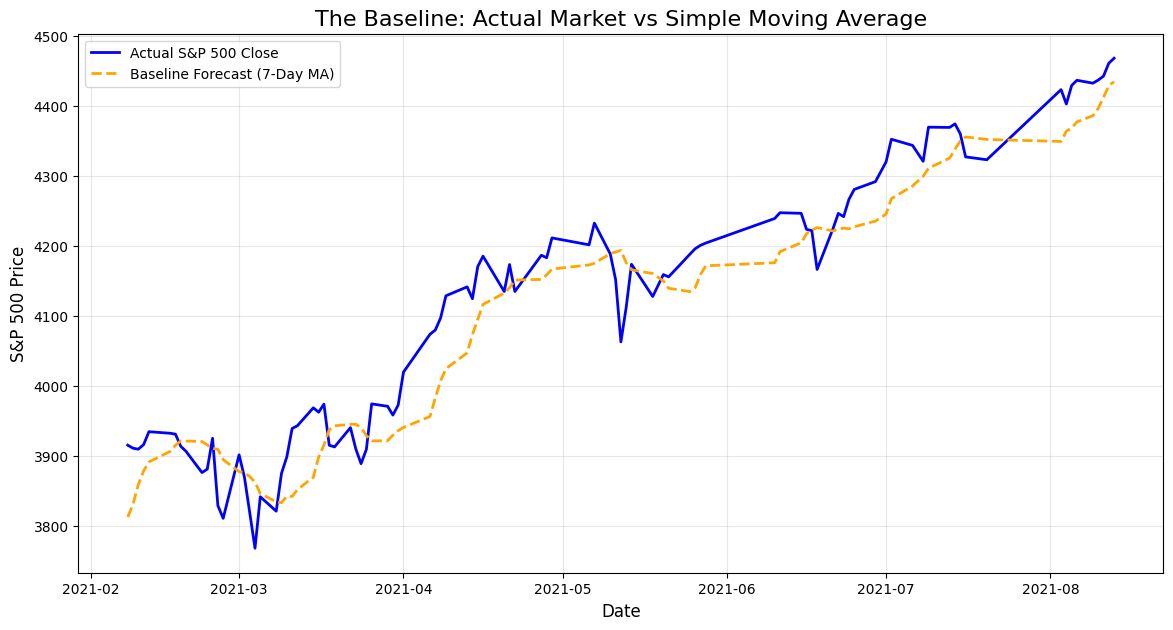

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

print("Loading final dataset...")
df = pd.read_csv('../assets/final_training_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# 1. Clean the outliers (Drop days with less than 50 posts like that 2020 row)
df = df[df['Post_Count'] > 50].reset_index(drop=True)
print(f"Cleaned dataset shape: {df.shape}")

# 2. THE BASELINE MODEL (7-Day Moving Average)
# We predict tomorrow's price by taking the average of the last 7 days
window_size = 7
df['Baseline_Prediction'] = df['SP500_Close'].rolling(window=window_size).mean().shift(1)

# Drop the first 7 days since they won't have a moving average yet
baseline_df = df.dropna(subset=['Baseline_Prediction']).copy()

# 3. Calculate how wrong the baseline is (Mean Absolute Error)
mae = mean_absolute_error(baseline_df['SP500_Close'], baseline_df['Baseline_Prediction'])
print(f"\nBaseline Mean Absolute Error (MAE): ${mae:.2f}")

# 4. Visualize the Baseline
plt.figure(figsize=(14, 7))
plt.plot(baseline_df['Date'], baseline_df['SP500_Close'], label='Actual S&P 500 Close', color='blue', linewidth=2)
plt.plot(baseline_df['Date'], baseline_df['Baseline_Prediction'], label='Baseline Forecast (7-Day MA)', color='orange', linestyle='--', linewidth=2)

plt.title('The Baseline: Actual Market vs Simple Moving Average', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('S&P 500 Price', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()